--------------------------------------------------
# Image Processing with OpenCV
--------------------------------------------------

------------------------------
## Task 0 - Capture Your Own Image Set (Prerequisite, do this first)
------------------------------
Using your phone or laptop webcam, capture 5 original images/clips today:
* A photo of yourself or a teammate (with their OK) in normal lighting
* The same subject/scene in low light
* A photo with at least 3 distinct small objects (pens, coins, keys) scattered on a desk
* A photo of a printed or handwritten page held at a slight angle
* A short 15 to 20 second video of you moving an object across the frame

Keep the original files as-is (don't screenshot or pre-edit them). You'll reuse these across the tasks below. Save them in a raw_captures/ folder inside your onboarding directory.

In [1]:
# imported the std libraries said in the document
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

folder_path = "./raw_captures/"

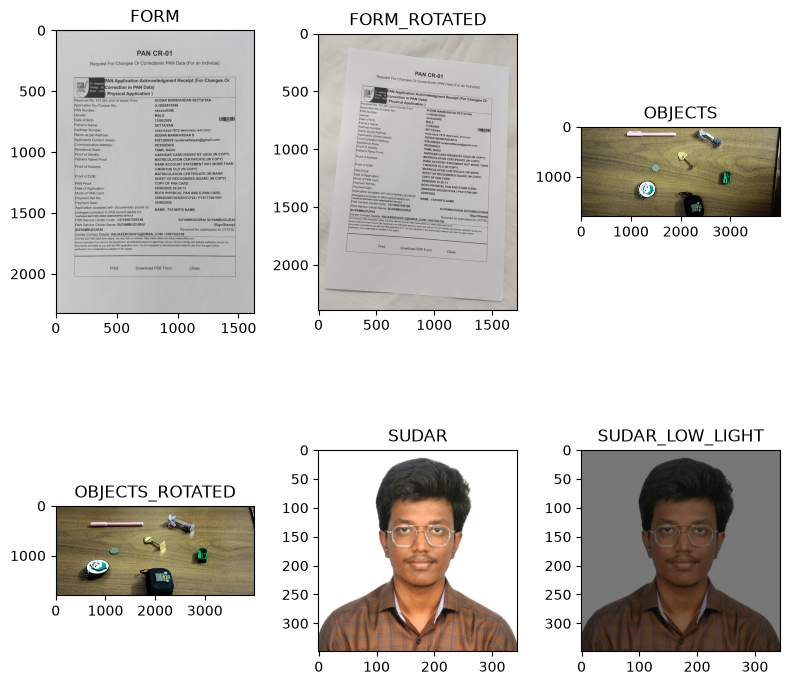

In [ ]:
import os

# thought we will need it often so made it as a function
def show_video(file_path):
    
    capture = cv.VideoCapture(os.path.join(folder_path, file_path))
    # print(os.path.join(folder_path, file_path))
    # check if opening file failes (due to permissions or error in format or API used)
    if not capture.isOpened():
        print("Can't open file.")
        exit(1)
        
    while True: # can also use cv.isOpen() function to check and exit
        status, frame = capture.read() 
            
        if not status:
            print("Video read successfully")
            break
        # control the size of window
        cv.namedWindow(str(file_path), cv.WINDOW_NORMAL)
        
        width = int(capture.get(cv.CAP_PROP_FRAME_WIDTH))
        height = int(capture.get(cv.CAP_PROP_FRAME_HEIGHT))
        
        center_w = (1920 - width) // 2
        center_h = (1080 - height) // 2
        
        cv.resizeWindow(str(file_path), width, height)
        cv.moveWindow(str(file_path), center_w, center_h)
        # display the frame
        cv.imshow(str(file_path), frame)
        
        # control the flow (using  0xFF as a filter to eliminate messy input scenarios)
        if cv.waitKey(30) & 0xFF == ord('q'):
            break
        
    capture.release()
    cv.destroyAllWindows()
    

allowed_extensions = (".jpeg", ".jpg", ".mp4")
fig, ax = plt.subplots(2, 3, figsize=(8, 8))
i = 0 

# display the  video and image stored in raw_captures folder
for file_path in sorted(os.listdir(folder_path)):
    
    if file_path.endswith(allowed_extensions) and (file_path.endswith("jpg") or file_path.endswith("jpeg")):
        row = i // 3; col = i % 3 
        # load and change the channel dim
        ax[row, col].imshow(cv.imread(os.path.join(folder_path, file_path))[:, :, :: -1])
        basename, _ = os.path.splitext(file_path)
        ax[row, col].set_title(basename.upper())
        # increment for next position
        i += 1
            
    elif file_path.endswith(".mp4"):
        show_video(file_path)

plt.tight_layout()
plt.show()   

-----------------------------------------
## Task 1 - Color Space Conversion
-------------------------------------------

Using your low-light photo, convert it to Grayscale, HSV, and RGB (remember OpenCV loads as BGR by default). Display all versions side by side.
Then, looking specifically at your own photo, note which HSV channel best preserves detail in the darkest part of the frame, and why you think that's the case for this particular shot.

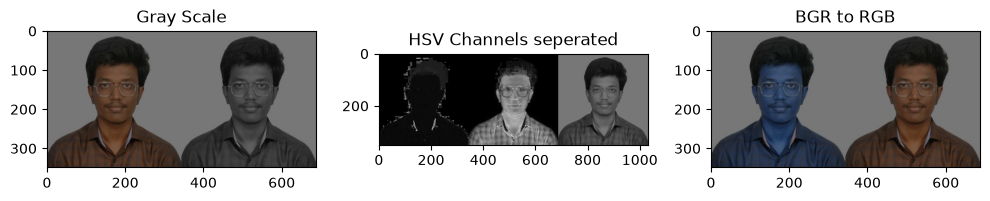

In [ ]:
low_light_picture = f"{folder_path}sudar_low_light.jpg"
img = cv.imread(low_light_picture)

if img is None:
    print(f"Error: Could not load image from {low_light_picture}")
    exit()

display_option = {"G": "Gray Scale", "H": "HSV", "R": "RGB"}
fig, ax  = plt.subplots(1, 3, figsize=(10, 8))
while True:
    key = input("Enter a key G -> Gray Scale, H -> HSV, R -> RGB (Any other key to Quit): ").upper()
    
    if key == "G":
        result = cv.cvtColor(img, cv.COLOR_BGR2GRAY)  
        display_result = cv.cvtColor(result, cv.COLOR_GRAY2BGR)
        combined_image = cv.hconcat([img, display_result])
        combined_img_plt = cv.hconcat([img[:, :, ::-1], display_result])
        ax[0].imshow(combined_img_plt)
        ax[0].set_title("Gray Scale")                
    elif key == "H":
        
        result = cv.cvtColor(img, cv.COLOR_BGR2HSV)
        # split channels and convert each to 3-channel BGR so cv.hconcat works without crash for 2nd time
        h, s, v = cv.split(result)
        h_bgr = cv.cvtColor(h, cv.COLOR_GRAY2BGR)
        s_bgr = cv.cvtColor(s, cv.COLOR_GRAY2BGR)
        v_bgr = cv.cvtColor(v, cv.COLOR_GRAY2BGR)
        
        # stack  H, S, V components
        combined_image = cv.hconcat([h_bgr, s_bgr, v_bgr])
        ax[1].imshow(combined_image)
        ax[1].set_title("HSV Channels seperated")
    elif key == "R":
        result = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        combined_image = cv.hconcat([img, result])
        ax[2].imshow(combined_image)
        ax[2].set_title("BGR to RGB")
    else:
        break

    # Display the temporary side-by-side comparison window
    cv.imshow(f"Combined Result ({display_option[key]})", combined_image)
    cv.waitKey(0)
    cv.destroyAllWindows()
plt.tight_layout()
plt.show()

### Task 1 - Observation

- The Value channel preserves the facial features as it is, in a low light image than the Hue and Saturation channels.

- The Value region preserves the most visible structure in shadowed regions because it directly captures brightness variations.

- The hue channel is mostly noisy, because of the presence of low colour based information in the image.

- The saturation region is responsible for intensity, preserves some features but they are over emphasized like the shirt and skin tone the other areas lost the details. 

------------------------------
## Task 2 - Image Blending via Feature Matching
------------------------------
Using your normal-light and low-light photos of the same scene, detect keypoints and descriptors in both with ORB, then match them with a brute-force (or FLANN) matcher. 

Use the good matches to estimate a homography with cv2.findHomography() (RANSAC), and warp the low-light photo onto the normal-light photo's plane with cv2.warpPerspective().

Once aligned, blend the two images with cv2.addWeighted() using at least two different weight combinations. Report how many good matches you found and comment on how well the homography aligned the two shots.

### The below block of code contains normal and low light image taken at same angle with no angle change. 

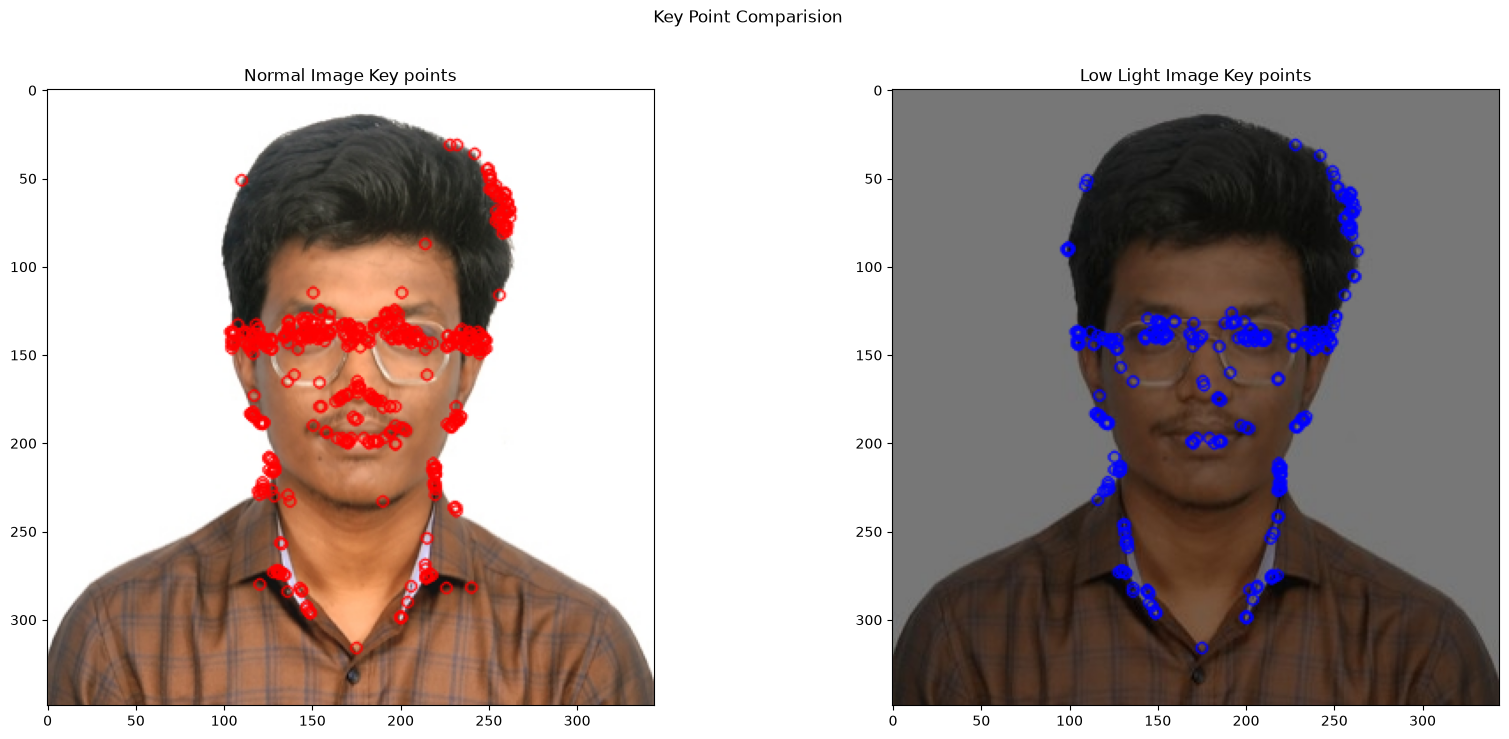

In [2]:
normal_img_path = f"{folder_path}sudar.jpg"
low_light_img_path = f"{folder_path}sudar_low_light.jpg"

# using Oriented FAST and Rotated Brief (ORB) method to detect key points and descriptors (blobs, textures)

normal_img = cv.imread(normal_img_path)
low_light_img = cv.imread(low_light_img_path)
# detect the keypoints and descriptors for normal image
orb = cv.ORB_create()

normal_keypoints, normal_descriptors = orb.detectAndCompute(cv.cvtColor(normal_img, cv.COLOR_BGR2GRAY), None)
low_light_keypoint, low_light_descriptor = orb.detectAndCompute(cv.cvtColor(low_light_img, cv.COLOR_BGR2GRAY), None)

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

normal_keypoint_image = cv.drawKeypoints(normal_img, normal_keypoints, None, color=(0, 0, 255))
lowlight_keypoint_image = cv.drawKeypoints(low_light_img, low_light_keypoint, None, color=(255, 0, 0))

ax[0].imshow(normal_keypoint_image[:,:, ::-1])
ax[0].set_title("Normal Image Key points")

ax[1].imshow(lowlight_keypoint_image[:, :, ::-1])
ax[1].set_title("Low Light Image Key points")

plt.suptitle("Key Point Comparision")
plt.show()

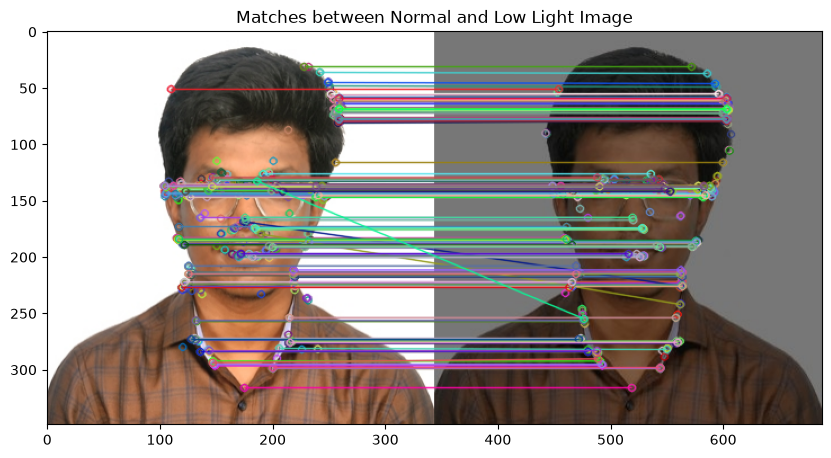

In [3]:
# match keypoints
matcher = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
result = matcher.match(normal_descriptors, low_light_descriptor)

# visualize match
match_result_img = cv.drawMatches(normal_img, normal_keypoints, 
                                 low_light_img, low_light_keypoint, result, None)
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(match_result_img, cv.COLOR_BGR2RGB))
plt.title("Matches between Normal and Low Light Image")
plt.show()

In [ ]:
# build homograph 
# sort match by distance
# good_match = sorted(result, key=lambda x: x.distance)[:30](not needed as bot image are )
#(not needed as bot image are identical can simply strip)

good_match = result[:30]

pt1 = np.float32([normal_keypoints[m.queryIdx].pt for m in good_match])
pt1 = pt1.reshape(-1, 1, 2)

pt2 = np.float32([low_light_keypoint[m.trainIdx].pt for m in good_match])
pt2 = pt2.reshape(-1, 1, 2)

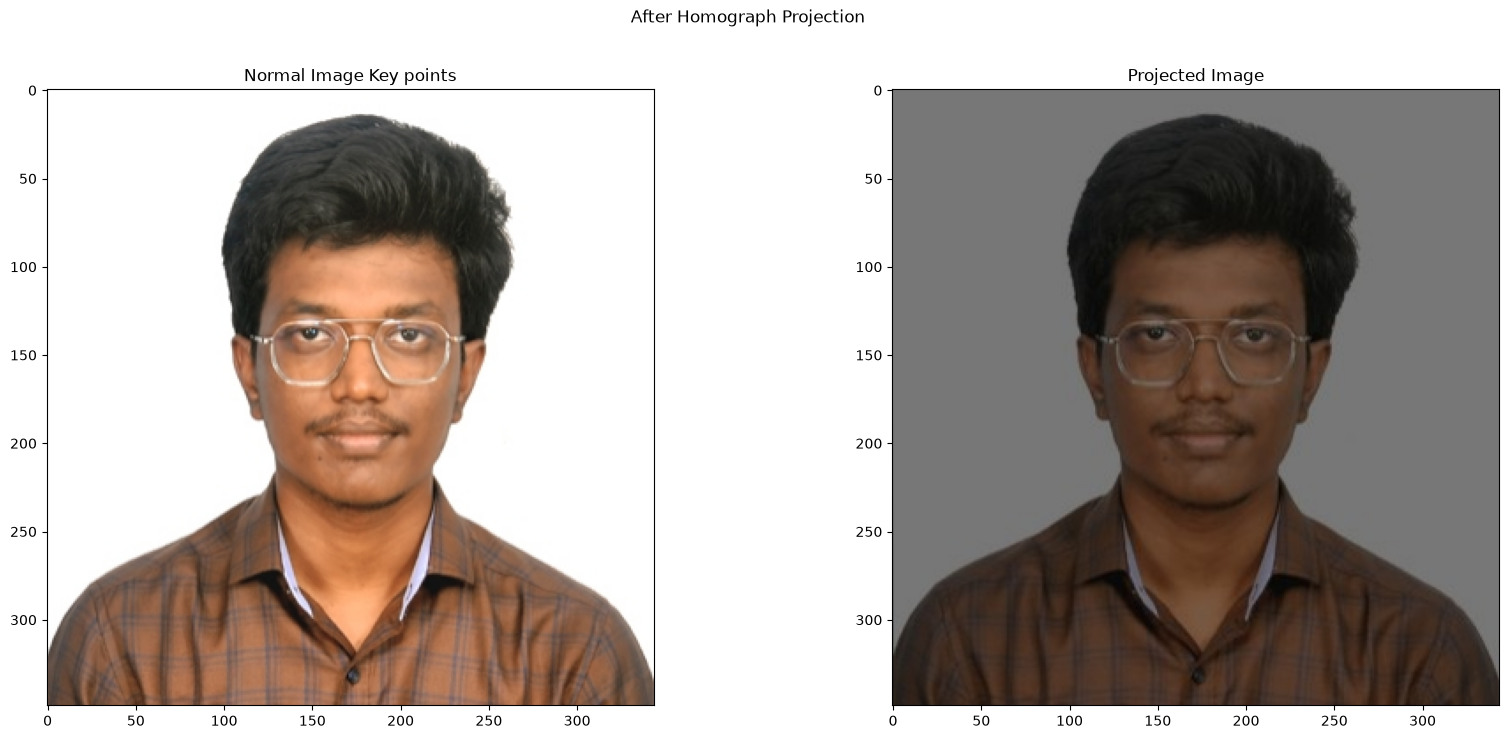

In [5]:
# homograph matrix 

hmatrix, mask = cv.findHomography(pt2, pt1, cv.RANSAC, 5.0)

# wrap one image over another using homograph matrix

img_new_perspective = cv.warpPerspective(low_light_img, hmatrix, 
                                         (normal_img.shape[1], normal_img.shape[0]))

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

ax[0].imshow(normal_img[:,:, ::-1])
ax[0].set_title("Normal Image Key points")

ax[1].imshow(img_new_perspective[:, :, ::-1])
ax[1].set_title("Projected Image")

plt.suptitle("After Homograph Projection")
plt.show()


In [7]:
print("The homograph matrix is: \n", hmatrix)

The homograph matrix is: 
 [[ 1.00066317e+00  1.76252769e-03 -3.10928202e-01]
 [-4.68647134e-04  1.00198462e+00 -9.00344502e-02]
 [-1.16742866e-06  5.01242774e-06  1.00000000e+00]]


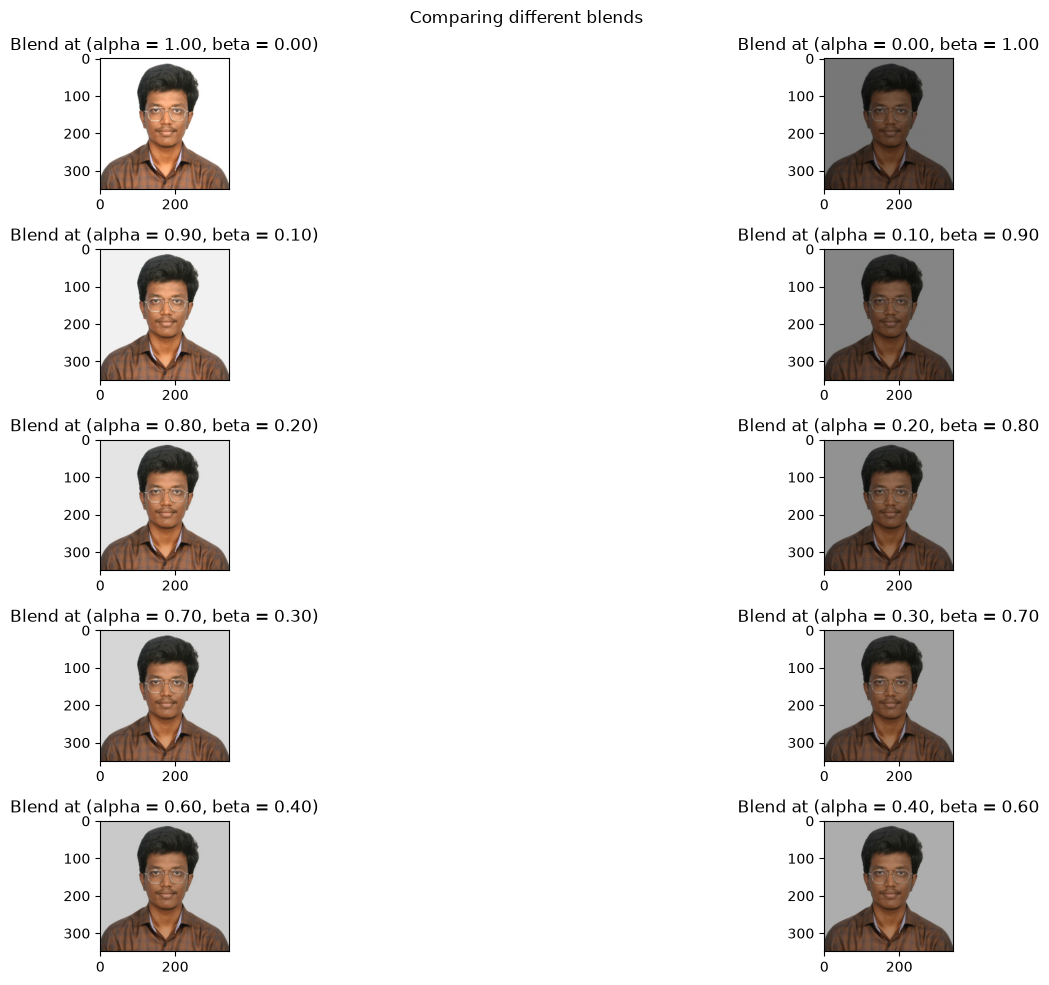

In [ ]:
# the blending of brightness must be always equal to 1 (else it will resultr in overshooting of brightness)
fig, ax = plt.subplots(5, 2, figsize=(20, 10))

# plotting some possible alpha dn Beta values for brightness
for i in range(5):
    blend_1 = cv.addWeighted(normal_img, 1 - i * 0.1, img_new_perspective, i * 0.1, 0)
    blend_2 = cv.addWeighted(normal_img, i * 0.1, img_new_perspective, 1 - i * 0.1, 0)
    ax[i][0].imshow(blend_1[:, :, :: -1])
    
    ax[i][0].set_title(f"Blend at (alpha = {1 - i * 0.1:.2f}, beta = { i * 0.1:.2f})")
    
    ax[i][1].imshow(blend_2[:, :, :: -1])
    ax[i][1].set_title(f"Blend at (alpha = {i * 0.1:.2f}, beta = { 1 - i * 0.1:.2f}")

plt.suptitle("Comparing different blends")
plt.tight_layout()
plt.show()

## Task 2 Observation

* Yes, The homograph aligned the images perfectly as the image was just a light adjusted version of a studio setup photograph. So the angles aligned perfectly, resulting in an pure translation form Homograph martix . The Homograph matrix confirms this

```text
                   h     1                 2                3        
Homograph Matrix = [[ 1.00066317e+00  1.76252769e-03 -3.10928202e-01]  1
                   [-4.68647134e-04  1.00198462e+00 -9.00344502e-02]  2
                   [-1.16742866e-06  5.01242774e-06  1.00000000e+00]] 3
```
    1. The h11 and h22 values that indicate scaling are (aprrox) 1. Indication a perfect  alignment (1:1 scale)
    2. The h12 and h21 are (approx) zero indicationg zero skewness
    3. The h13 and h23 , horizontal and vertical translation(shift) are nearly zero or very less, meaning the pixel are not moved very much between 2 images.
    4. The values h31 and h32 are also nearly zero indication no 3D rotaion in the image.

* The good combinations as per my observation is lies between (alpha = 0.70 to alpha = 0.90). As this yields the bright nature over the image over the dark background giving a sense of the person being highlighted, like a splotligh effect.



## References for code
* [Detecting and Tracking object using ORB -  siromer | Medium](https://medium.com/thedeephub/detecting-and-tracking-objects-with-orb-using-opencv-d228f4c9054e)
* [Homograph/Feature Matching by jeffcrouse](https://forum.derivative.ca/t/feature-matching-homography-with-orb-sift-brisk-etc/622687)
* [Homograph - GFG](https://www.geeksforgeeks.org/computer-vision/what-is-homography-how-to-estimate-homography-between-two-images/)
* [Wrap Persepctive - The AI Learner](https://theailearner.com/tag/cv2-warpperspective/)
* [Blend Image - GFG](https://www.geeksforgeeks.org/computer-vision/image-blending-using-opencv/)


-------------------
## Task - 3 Geometric Transformations
-------------------
Pick a personal reference number: the last 2 digits of your employee ID (or, if you don't have one yet, the last 2 digits of your phone number). Compute angle = (your number) x 3 degrees and scale = 1 + (last digit of your number / 10).

Apply translation, this rotation, this scale factor, and one affine transform to your objects photo. State the reference number and computed values explicitly in your notebook so your mentor can double check them.

Chosen Digit:  29
Angle 87
Scaling factor 1.9


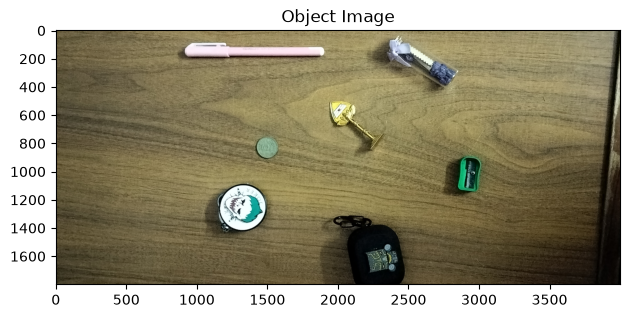

In [2]:
digits = 29
angle = (digits * 3) % 360
scale = (1 + digits % 10 / 10)

print("Chosen Digit: ", digits)
print("Angle", angle)
print("Scaling factor", scale)

object_image = cv.imread(f"{folder_path}objects.jpeg")
plt.imshow(object_image[:, :, ::-1])
plt.title("Object Image")
plt.tight_layout()
plt.show()

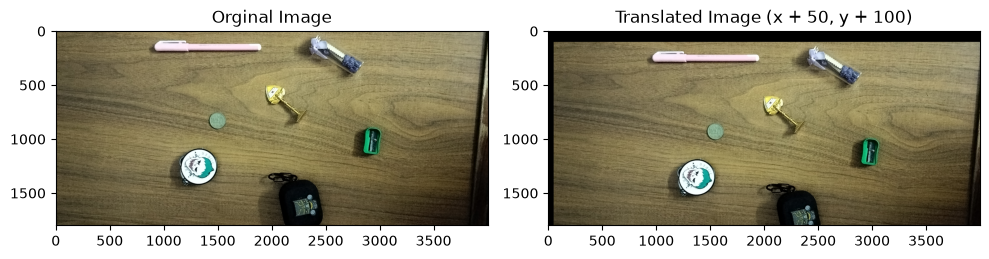

In [3]:
# to apply translation (movement across x and y plane) build a affine mmatrix of format
'''
    M = [[1, 0, tx], tx -> pixel to be moved along x
         [0, 1, ty]] ty -> pixel to be moved along y
''' 

tx, ty = 50, 100
h, w = object_image.shape[:2]
m_translate = np.float32([[1, 0, tx],
               [0, 1, ty]])

translated_object_image = cv.warpAffine(object_image, m_translate, (w, h))

fig, ax = plt.subplots(1, 2, figsize=(10, 8))

ax[0].imshow(object_image[:, :, ::-1])
ax[0].set_title("Orginal Image")

ax[1].imshow(translated_object_image[:, :, ::-1])
ax[1].set_title(f"Translated Image (x + {tx}, y + {ty})")

plt.tight_layout()
plt.show()

Matrix for rotation by 87
 [[ 5.23359562e-02  9.98629535e-01  9.96561506e+02]
 [-9.98629535e-01  5.23359562e-02  2.85015671e+03]]
Matrix for scaling by 1.9 factor
 [[    1.9     0.  -1800. ]
 [   -0.      1.9  -810. ]]
Matrix for both rotaion and scaling
 [[ 9.94383169e-02  1.89739612e+00  9.34668618e+01]
 [-1.89739612e+00  9.94383169e-02  4.60529775e+03]]


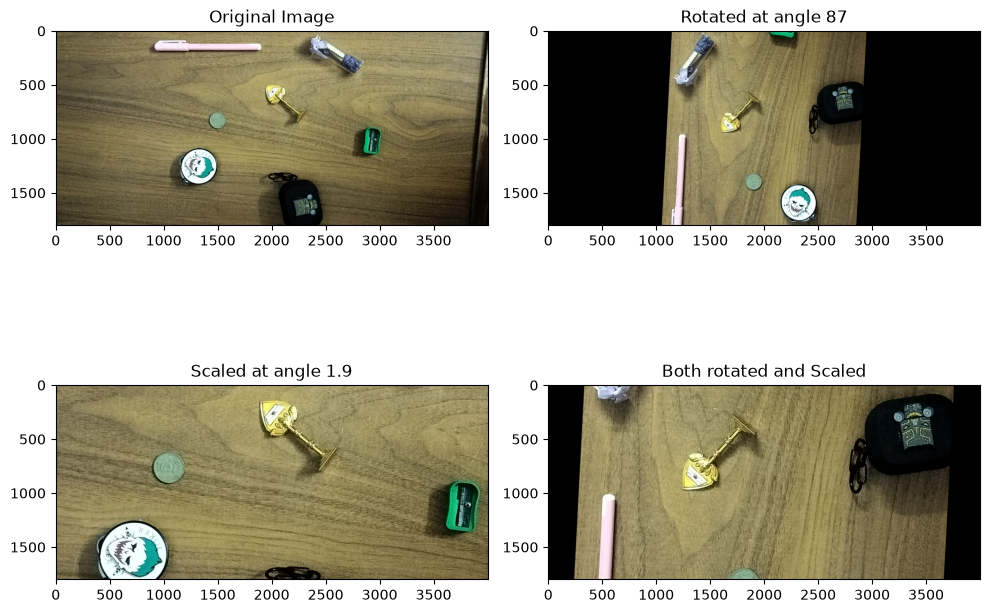

In [18]:
# applying rotation
center = (w // 2, h // 2)
# consider only angle change
rotation_matrix1 = cv.getRotationMatrix2D(center, angle, scale=1.0)
# consider only scaling
rotation_matrix2 = cv.getRotationMatrix2D(center, angle=0.0, scale=scale)
# apply both angle and scale
rotation_matrix3 = cv.getRotationMatrix2D(center, angle=angle, scale=scale)

# using wrap affine similarly
rotated_img1 = cv.warpAffine(object_image, rotation_matrix1, (w, h))
rotated_img2 = cv.warpAffine(object_image, rotation_matrix2, (w, h))
rotated_img3 = cv.warpAffine(object_image, rotation_matrix3, (w, h))

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

print(f"Matrix for rotation by {angle}\n", rotation_matrix1)
print(f"Matrix for scaling by {scale} factor\n", rotation_matrix2)
print(f"Matrix for both rotaion and scaling\n", rotation_matrix3)

ax[0][0].imshow(object_image[:, :, ::-1])
ax[0][0].set_title("Original Image")

ax[0][1].imshow(rotated_img1[:, :, ::-1])
ax[0][1].set_title(f"Rotated at angle {angle}")

ax[1][0].imshow(rotated_img2[:, :, ::-1])
ax[1][0].set_title(f"Scaled at angle {scale}")

ax[1][1].imshow(rotated_img3[:, :, ::-1])
ax[1][1].set_title(f"Both rotated and Scaled")

plt.tight_layout()
plt.show()

Affine Matrix
 [[  0.49726776   1.17486339 -51.91256831]
 [ -0.44262295   1.82786885 140.16393443]]


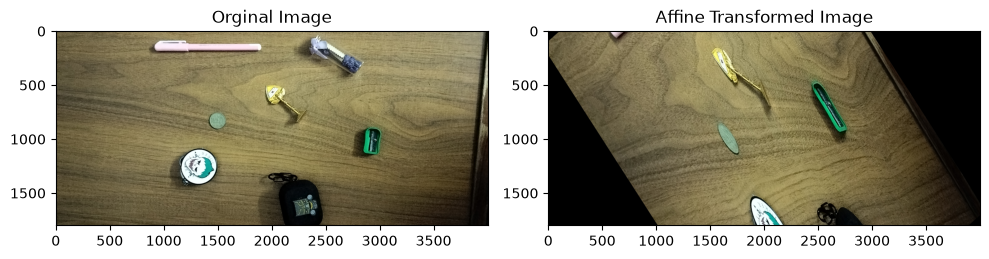

In [16]:
# affine point trnsformation

ctrl_pt1 = np.float32([[30, 40], 
            [w // 2, h //2],
            [200, 300]])
# fixing along the center for clear visual 
ctrl_pt2 = np.float32([[10, 200],
            [w // 2, h // 2],
            [400, 600]])

m_affine = cv.getAffineTransform(ctrl_pt1, ctrl_pt2)
print("Affine Matrix\n", m_affine)
transformed_img = cv.warpAffine(object_image, m_affine, (w, h))

fig, ax = plt.subplots(1, 2, figsize=(10, 8))

ax[0].imshow(object_image[:, :, ::-1])
ax[0].set_title("Orginal Image")

ax[1].imshow(transformed_img[:, :, ::-1])
ax[1].set_title("Affine Transformed Image")

plt.tight_layout()
plt.show()

## Task 3 - Observations

- The translation matrix is used to shift every pixel in the image by a fixed amount. It follows the equations
  - x_new = x + trans_x
  - y_new = y + trans_y

- When a pure rotation of 87 deg (with scale = 1) is applied, the transformation matrix obtained is

```text
[[ 5.23359562e-02  9.98629535e-01  9.96561506e+02]
 [-9.98629535e-01  5.23359562e-02  2.85015671e+03]]
```

which can be represented as

```text
[[ cos(87 deg)   sin(87 deg)   tx ]
 [-sin(87 deg)   cos(87 deg)   ty ]]
```
- The diagonal elements correspond to cos(87 deg).
- The off-diagonal elements correspond to sin(87 deg) or -sin(87 deg).
- The rotation matrix preserves the shape and size of the object since the scale factor is 1.
- The translation terms (`tx`, `ty`) are automatically computed by OpenCV to keep the rotation centered at the specified image center instead of the image origin.

- When pure scaling of 1.9 (with angle = 0 deg) is applied, the transformation matrix becomes,

```text
[[   1.9    0.0  -1800.0]
 [  -0.0    1.9   -810.0]]
```

which can be written as

```text
[[ scale   0      tx ]
 [   0    scale   ty ]]
```
- Both diagonal elements are equal to the scaling factor (1.9), indicating uniform scaling in both x and y directions.
- Since the rotation angle is 0 deg, there are no sine terms.
- The translation components compensate for the enlargement so that the scaling is performed about the image center rather than the top-left corner.

- When both rotation (87 deg) and scaling (1.9) are applied simultaneously, the transformation matrix becomes:

```text
[[ 9.94383169e-02  1.89739612e+00  9.34668618e+01]
 [-1.89739612e+00  9.94383169e-02  4.60529775e+03]]
```

which can be represented as

```text
[[ scale × cos(87 deg)    scale × sin(87 deg)    tx ]
 [-scale × sin(87 deg)    scale × cos(87 deg)    ty ]]
```

- Each rotation coefficient is multiplied by the scaling factor.
- The matrix simultaneously rotates and enlarges the image in a single affine transformation.
- The translation components ensure that both the rotation and scaling are performed about the specified center of the image, preventing the transformed image from shifting away from its intended position.

- The translation, rotation, and scaling operations performed above are all special cases of affine transformations. In general, an affine transformation is obtained by selecting three corresponding points in the source and destination images. The transformation matrix then combines translation, rotation, scaling, and shearing to map the source image onto the destination image while preserving straight lines and parallelism. 
- The selected points must not be collinear.

## References

- [Concept of rotation in OpenCV](https://data-flair.training/blogs/geometric-transformations-of-images-using-opencv/#:~:text=Rotation%20and%20Scaling%20in%20OpenCV%3A%20Reshaping%20Reality%20with%20Precision)
- [Affine Transfromation, rotation code - OpenCV 5.0 documentation](https://docs.opencv.org/5.0/py_tutorials/py_imgproc/py_geometric_transformations/py_geometric_transformations.html#affine-transformation)